# 00 — Data Preprocessing
## SpiriCom PFE · Huawei Technologies Tunisia · 2026

**Datasets:**
- `real_complaints.xlsx` — 2025 Complaint records
- `dataCollectionist.csv` — Network KPI / User Traffic (4,899 rows)

**Key rule for Dataset 2:** Any column with ≥ 80% null values is **automatically dropped**.

**Outputs saved to `data/processed/`:**
- `complaints_clean.parquet`
- `kpi_clean.parquet`
- `preprocessing_report.json`
- `dropped_columns_report.csv`

In [1]:
# ── 0.0  Imports & setup ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import json
import os
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ─────────────────────────────────────────────────────────────
RAW_DIR  = Path('data/raw')
PROC_DIR = Path('data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

# Adjust filenames if yours differ
COMPLAINTS_FILE = RAW_DIR / 'real_complaints.xlsx'
KPI_FILE        = RAW_DIR / 'dataCollectionist.csv'

# ── Constants ─────────────────────────────────────────────────────────
NULL_DROP_THRESHOLD = 0.95   # Drop columns with >= 95% nulls

print('✅ Setup complete')
print(f'   Raw dir    : {RAW_DIR.resolve()}')
print(f'   Processed  : {PROC_DIR.resolve()}')

✅ Setup complete
   Raw dir    : C:\Users\c50057188\Desktop\PFE_Ouerghi\data\raw
   Processed  : C:\Users\c50057188\Desktop\PFE_Ouerghi\data\processed


## PART A — Dataset 1: real_complaints.xlsx

In [2]:
# ── A.1  Load complaints ──────────────────────────────────────────────
df_comp = pd.read_excel(COMPLAINTS_FILE, engine='openpyxl')
print(f'Loaded complaints: {df_comp.shape[0]:,} rows × {df_comp.shape[1]} columns')
df_comp.head(3)

Loaded complaints: 25,727 rows × 17 columns


,Case ID,system,case open datetime,Type,msisdn,last status,Provider Group,typologie It/network,category,sub category,sub sub category,province,city,Segment MSISDN CONCERN,bscs_custcode,account contact name,Week
0,TT546791,DCLM,2025-01-01 00:44:14,Complaint,21100376.0000,closed,GIS,Network,RÉSEAU,Réclamation réseau mobile DATA,Débit faible Internet mobile,Tunis Gouvernorat,Le Kram,Premium,1.60474609,BASSEM MAHMDI,NaN
1,TT546829,DCLM,2025-01-01 08:21:08,Complaint,26136691.0000,resolved,GIS,Network,RÉSEAU,Réclamation réseau mobile Voix,Pas de couverture Voix,Ben Arous Gouvernorat,Mornag,LowEndUser,5.39863.10.00.104360,Amicale du Ministère de lAgriculture,NaN
2,TT547176,DCLM,2025-01-01 11:30:40,Complaint,24475205.0000,closed,GIS,Network,RÉSEAU,Réclamation réseau mobile DATA,Débit faible Internet mobile,Gafsa Gouvernorat,Gafsa,LowEndUser,5.57107.00.00.101444,Amicale Agents Territoire Metlaoui CPJ,NaN


In [3]:
# ── A.2  Schema & null audit ──────────────────────────────────────────
comp_null_pct = (df_comp.isnull().mean() * 100).round(2)
comp_schema = pd.DataFrame({
    'dtype'   : df_comp.dtypes,
    'n_unique' : df_comp.nunique(),
    'null_pct' : comp_null_pct,
    'sample'  : df_comp.iloc[0],
}).sort_values('null_pct', ascending=False)

print('=== Complaints — Column Audit ===')
print(comp_schema.to_string())

=== Complaints — Column Audit ===
                                 dtype  n_unique  null_pct                          sample
Week                           float64         0  100.0000                             NaN
city                            object       257    9.7600                         Le Kram
province                        object        24    9.2300               Tunis Gouvernorat
account contact name            object     14743    0.4000                   BASSEM MAHMDI
bscs_custcode                   object     21625    0.0100                      1.60474609
Case ID                         object     25727    0.0000                        TT546791
system                          object         1    0.0000                            DCLM
Type                            object         2    0.0000                       Complaint
case open datetime      datetime64[ns]     25705    0.0000             2025-01-01 00:44:14
category                        object         3    0.00

In [4]:
# ── A.3  Standardise column names ────────────────────────────────────
def clean_col(c):
    return (c.strip()
             .lower()
             .replace(' ', '_')
             .replace('/', '_')
             .replace('-', '_'))

df_comp.columns = [clean_col(c) for c in df_comp.columns]

# Canonical column mapping for known complaint columns
COL_MAP_COMP = {
    'case_id'               : 'case_id',
    'system'                : 'system',
    'case_open_datetime'    : 'opened_at',
    'type'                  : 'complaint_type',
    'msisdn'                : 'msisdn',
    'last_status'           : 'status',
    'provider_group'        : 'provider_group',
    'typologie_it_network'  : 'typology',
    'category'              : 'category',
    'sub_category'          : 'sub_category',
    'sub_sub_category'      : 'sub_sub_category',
    'province'              : 'province',
    'city'                  : 'city',
    'segment_msisdn_concern': 'segment',
    'bscs_custcode'         : 'cust_code',
    'account_contact_name'  : 'contact_name',
    'week'                  : 'week',
}
df_comp.rename(columns=COL_MAP_COMP, inplace=True)

print('Columns after rename:', df_comp.columns.tolist())

Columns after rename: ['case_id', 'system', 'opened_at', 'complaint_type', 'msisdn', 'status', 'provider_group', 'typology', 'category', 'sub_category', 'sub_sub_category', 'province', 'city', 'segment', 'cust_code', 'contact_name', 'week']


In [5]:
# ── A.4  Datetime parsing ────────────────────────────────────────────
df_comp['opened_at'] = pd.to_datetime(df_comp['opened_at'], errors='coerce')

df_comp['year']       = df_comp['opened_at'].dt.year
df_comp['month']      = df_comp['opened_at'].dt.month
df_comp['day_of_week']= df_comp['opened_at'].dt.dayofweek   # 0=Mon
df_comp['quarter']    = df_comp['opened_at'].dt.quarter
df_comp['week_num']   = df_comp['opened_at'].dt.isocalendar().week.astype(int)

date_min = df_comp['opened_at'].min()
date_max = df_comp['opened_at'].max()
print(f'Date range : {date_min.date()} → {date_max.date()}')
print(f'Null dates : {df_comp["opened_at"].isnull().sum()}')

Date range : 2025-01-01 → 2025-12-03
Null dates : 0


In [6]:
# ── A.5  String normalisation ────────────────────────────────────────
STR_COLS_COMP = ['complaint_type', 'status', 'provider_group', 'typology',
                 'category', 'sub_category', 'sub_sub_category',
                 'province', 'city', 'segment']

for col in STR_COLS_COMP:
    if col in df_comp.columns:
        df_comp[col] = (df_comp[col]
                        .astype(str)
                        .str.strip()
                        .str.upper()
                        .replace({'NAN': np.nan, 'NONE': np.nan, '': np.nan}))

# Normalise MSISDN: remove country code prefix variations
df_comp['msisdn'] = (df_comp['msisdn'].astype(str)
                     .str.replace(r'[^0-9]', '', regex=True)
                     .str.lstrip('0')
                     .str.lstrip('216'))

print('String normalisation complete')
print('Status values:', df_comp['status'].value_counts().to_dict())

String normalisation complete
Status values: {'CLOSED': 12669, 'OPEN': 12558, 'IN PROGRESS RETURN FOR PROCESSING': 211, 'CLOSED ALERT RESOLVED': 204, 'RESOLVED': 56, 'IN PROGRESS DT': 7, 'RESOLVED DT': 7, 'INPROGRESS': 6, 'IN PROGRESS RETURN NOT COMPLETE': 3, 'CLOSED REFUNDED': 2, 'CLOSED DTFO': 1, 'IN PROGRESS UNFOUNDED RETURN': 1, 'CANCELLED': 1, 'REASSIGN': 1}


In [7]:
# ── A.6  Churn label (Dataset 1 contribution) ────────────────────────
# Definition used across notebooks:
#   is_unresolved  = status NOT IN ('CLOSED', 'RESOLVED', 'FERME', 'CLOTURE')
#   churn flag built in 04_Churn_Feature_Engineering

RESOLVED_STATUSES = {'CLOSED', 'RESOLVED', 'FERME', 'CLOTURE',
                     'CLOSE', 'CLOS', 'RESOLU'}

df_comp['is_unresolved'] = (~df_comp['status'].isin(RESOLVED_STATUSES)).astype(int)

print('Unresolved rate:', df_comp['is_unresolved'].mean().round(3))
print('Status distribution:')
print(df_comp['status'].value_counts().head(10))

Unresolved rate: 0.505
Status distribution:
status
CLOSED                               12669
OPEN                                 12558
IN PROGRESS RETURN FOR PROCESSING      211
CLOSED ALERT RESOLVED                  204
RESOLVED                                56
IN PROGRESS DT                           7
RESOLVED DT                              7
INPROGRESS                               6
IN PROGRESS RETURN NOT COMPLETE          3
CLOSED REFUNDED                          2
Name: count, dtype: int64


In [8]:
# ── A.7  Duplicates ──────────────────────────────────────────────────
n_before = len(df_comp)
df_comp.drop_duplicates(subset='case_id', keep='first', inplace=True)
n_after  = len(df_comp)
print(f'Duplicates removed: {n_before - n_after:,}  ({n_after:,} remaining)')

Duplicates removed: 0  (25,727 remaining)


In [9]:
# ── A.8  Save complaints ─────────────────────────────────────────────
comp_path = PROC_DIR / 'complaints_clean.parquet'
df_comp.to_parquet(comp_path, index=False)
print(f'✅ Saved: {comp_path}  ({df_comp.shape[0]:,} rows × {df_comp.shape[1]} cols)')
df_comp.dtypes

✅ Saved: data\processed\complaints_clean.parquet  (25,727 rows × 23 cols)


case_id                     object
system                      object
opened_at           datetime64[ns]
complaint_type              object
msisdn                      object
status                      object
provider_group              object
typology                    object
category                    object
sub_category                object
sub_sub_category            object
province                    object
city                        object
segment                     object
cust_code                   object
contact_name                object
week                       float64
year                         int32
month                        int32
day_of_week                  int32
quarter                      int32
week_num                     int64
is_unresolved                int64
dtype: object

## PART B — Dataset 2: dataCollectionist.csv

In [10]:
# ── B.1  Load KPI data ───────────────────────────────────────────────
# Try comma first, fall back to semicolon (common in French exports)
try:
    df_kpi = pd.read_csv(KPI_FILE, low_memory=False)
    if df_kpi.shape[1] < 5:
        df_kpi = pd.read_csv(KPI_FILE, sep=';', low_memory=False)
except Exception:
    df_kpi = pd.read_csv(KPI_FILE, sep=';', low_memory=False)

print(f'Loaded KPI data: {df_kpi.shape[0]:,} rows × {df_kpi.shape[1]} columns')
df_kpi.head(3)

Loaded KPI data: 4,898 rows × 132 columns


,TIMEE,imsi,msisdn,usim_flag,mcc,mnc,roaming_direction,tac,model,tertype,brand,sim_capability,generation,volte_flag,traffic_2g,traffic_3g,traffic_4g,traffic_5G,duration,voice_onlinetime_3g,voice_onlinetime_2g,Dou_Total,game_traffic,Streaming_traffic,IM_traffic,...,CCR_U,CCR_I_GX,CCR_U_GX,Gr_Send_Authentication_Information_SR,Gr_Update_Location_SR,S5_S8_Default_Bearer_Creation_SR,S3S10Context_SR,GnGpCreate_PDP_Context_Procedure_SR,SGs_Location_Update_Success_Rate,SGs_Paging_Success_Rate,SGs_SMS_Origination_Success_Rate,SGs_SMS_Termination_Success_Rate,User_Class,number_of_regions,mobility_class,dns_delay,DNS_SR,session_flag,reserved_field5,Speedtest_traffic,nPerf_traffic,apn,reserved_field1,reserved_field2,MSISDN
0,3/1/2025,605000000000000.0000,92411456,NaN,605,2,inbound_roamer,864000000000000.0000,Z2359,SmartPhone,ZTE,NaN,2G/3G/LTE,NaN,NaN,NaN,84504.0000,NaN,225.0000,225.0000,NaN,84504.0000,NaN,NaN,NaN,...,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,1.0000,1.0000,NaN,1.0000,Other_traffic,2.0000,High Mobility,NaN,0.0000,0.0000,0.0000,NaN,NaN,INTERNET.TN,NaN,NaN,92411456
1,3/1/2025,605000000000000.0000,94333771,NaN,605,2,inbound_roamer,867000000000000.0000,REDMI A1+,SmartPhone,XIAOMI,NaN,2G/3G/LTE,NaN,NaN,9882.0000,25188.0000,NaN,505.0000,93.0000,412.0000,35070.0000,NaN,NaN,NaN,...,1.0000,1.0000,1.0000,NaN,1.0000,NaN,NaN,NaN,1.0000,1.0000,NaN,1.0000,Other_traffic,2.0000,High Mobility,7.9250,1.0000,0.0000,0.0000,NaN,NaN,INTERNET.TN,NaN,NaN,94333771
2,3/1/2025,605000000000000.0000,97860919,1.0000,605,2,inbound_roamer,350000000000000.0000,X657C,SmartPhone,INFINIX,NaN,2G/3G/LTE,NaN,NaN,36911.0000,255169910.0000,NaN,76.0000,76.0000,NaN,255206821.0000,NaN,99001998.0000,557761.0000,...,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,1.0000,1.0000,NaN,1.0000,Web_Browsing_traffic,2.0000,High Mobility,2.4547,0.9992,0.0000,0.0000,NaN,NaN,INTERNET.TN,NaN,NaN,97860919


In [11]:
# ── B.2  NULL AUDIT — The critical step ─────────────────────────────
#   Rule: Any column with >= 80% null values is DROPPED

null_pct      = df_kpi.isnull().mean()
null_report   = (null_pct * 100).round(2).sort_values(ascending=False)
cols_to_drop  = null_pct[null_pct >= NULL_DROP_THRESHOLD].index.tolist()
cols_to_keep  = null_pct[null_pct <  NULL_DROP_THRESHOLD].index.tolist()

print(f'Total columns     : {df_kpi.shape[1]}')
print(f'Columns DROPPED   : {len(cols_to_drop)}  (>= {NULL_DROP_THRESHOLD*100:.0f}% null)')
print(f'Columns RETAINED  : {len(cols_to_keep)}')
print()
print('--- DROPPED columns ---')
for c in cols_to_drop:
    print(f'  {c:50s}  {null_report[c]:.1f}% null')

Total columns     : 132
Columns DROPPED   : 14  (>= 95% null)
Columns RETAINED  : 118

--- DROPPED columns ---
  sim_capability                                      100.0% null
  volte_flag                                          100.0% null
  FreeFire_traffic                                    96.9% null
  PUBG_traffic                                        100.0% null
  Video_Streaming_Start_Success_Rate                  100.0% null
  Video_Streaming_Start_Delay                         100.0% null
  Video_Streaming_Stall_Frequency                     100.0% null
  E_RAB_SR                                            98.8% null
  S5_S8_Default_Bearer_Creation_SR                    99.9% null
  S3S10Context_SR                                     99.9% null
  Speedtest_traffic                                   99.3% null
  nPerf_traffic                                       99.9% null
  reserved_field1                                     100.0% null
  reserved_field2                    

In [12]:
# ── B.3  Save dropped-column report ─────────────────────────────────
drop_df = pd.DataFrame({
    'column'   : cols_to_drop,
    'null_pct' : [null_report[c] for c in cols_to_drop],
    'reason'   : f'>= {NULL_DROP_THRESHOLD*100:.0f}% null values',
})
drop_report_path = PROC_DIR / 'dropped_columns_report.csv'
drop_df.to_csv(drop_report_path, index=False)
print(f'✅ Dropped columns report saved: {drop_report_path}')
print(drop_df.to_string(index=False))

✅ Dropped columns report saved: data\processed\dropped_columns_report.csv
                            column  null_pct             reason
                    sim_capability  100.0000 >= 95% null values
                        volte_flag  100.0000 >= 95% null values
                  FreeFire_traffic   96.9200 >= 95% null values
                      PUBG_traffic  100.0000 >= 95% null values
Video_Streaming_Start_Success_Rate  100.0000 >= 95% null values
       Video_Streaming_Start_Delay  100.0000 >= 95% null values
   Video_Streaming_Stall_Frequency  100.0000 >= 95% null values
                          E_RAB_SR   98.7500 >= 95% null values
  S5_S8_Default_Bearer_Creation_SR   99.9200 >= 95% null values
                   S3S10Context_SR   99.9400 >= 95% null values
                 Speedtest_traffic   99.3500 >= 95% null values
                     nPerf_traffic   99.9000 >= 95% null values
                   reserved_field1  100.0000 >= 95% null values
                   reserved_fi

In [13]:
# ── B.4  Drop high-null columns ──────────────────────────────────────
df_kpi.drop(columns=cols_to_drop, inplace=True)
print(f'Shape after drop: {df_kpi.shape[0]:,} rows × {df_kpi.shape[1]} columns')
print('Retained columns:')
for c in df_kpi.columns:
    print(f'  {c:50s}  {null_report.get(c, 0):.1f}% null')

Shape after drop: 4,898 rows × 118 columns
Retained columns:
  TIMEE                                               0.0% null
  imsi                                                0.0% null
  msisdn                                              0.0% null
  usim_flag                                           23.6% null
  mcc                                                 0.0% null
  mnc                                                 0.0% null
  roaming_direction                                   0.0% null
  tac                                                 0.0% null
  model                                               0.0% null
  tertype                                             0.0% null
  brand                                               0.0% null
  generation                                          0.0% null
  traffic_2g                                          80.4% null
  traffic_3g                                          41.4% null
  traffic_4g                            

In [14]:
# ── B.5  Standardise column names ────────────────────────────────────
df_kpi.columns = [clean_col(c) for c in df_kpi.columns]

# Unify msisdn column (file has both 'msisdn' and 'msisdn' at end)
# Keep first occurrence
if df_kpi.columns.duplicated().any():
    df_kpi = df_kpi.loc[:, ~df_kpi.columns.duplicated(keep='first')]
    print('Deduplicated column names')

print('Column list:', df_kpi.columns.tolist())

Deduplicated column names
Column list: ['timee', 'imsi', 'msisdn', 'usim_flag', 'mcc', 'mnc', 'roaming_direction', 'tac', 'model', 'tertype', 'brand', 'generation', 'traffic_2g', 'traffic_3g', 'traffic_4g', 'traffic_5g', 'duration', 'voice_onlinetime_3g', 'voice_onlinetime_2g', 'dou_total', 'game_traffic', 'streaming_traffic', 'im_traffic', 'web_browsing_traffic', 'other_traffic', 'voip_traffic', 'sms_traffic', 'tiktok_traffic', 'instagram_traffic', 'facebook_traffic', 'facebook_messenger_traffic', 'https_traffic', 'quic_ietf_traffic', 'youtube_traffic', 'google_common_traffic', 'whatsapp_traffic', 'googlesearch_traffic', 'night_traffic', 'day_traffic', 'late_night_traffic', 'usertype', 'home_cell', 'home_site', 'site_name', 'layer1name', 'layer2name', 'layer3name', 'ran_ne_vendor', 'longitude', 'latitude', 'video_streaming_download_throughput', 'video_xkb_start_delay', 'page_response_success_rate', 'page_response_delay', 'page_browsing_success_rate', 'page_browsing_delay', 'page_downl

In [15]:
# ── B.6  Datetime parsing ────────────────────────────────────────────
# TIMEE column — try multiple formats
time_col = next((c for c in df_kpi.columns if 'time' in c.lower()), None)
if time_col:
    df_kpi[time_col] = pd.to_datetime(df_kpi[time_col], errors='coerce', infer_datetime_format=True)
    df_kpi.rename(columns={time_col: 'timestamp'}, inplace=True)
    df_kpi['date']        = df_kpi['timestamp'].dt.date
    df_kpi['hour']        = df_kpi['timestamp'].dt.hour
    df_kpi['day_of_week'] = df_kpi['timestamp'].dt.dayofweek
    df_kpi['week_num']    = df_kpi['timestamp'].dt.isocalendar().week.astype('Int64')
    df_kpi['month']       = df_kpi['timestamp'].dt.month
    print(f'Timestamp range: {df_kpi["timestamp"].min()} → {df_kpi["timestamp"].max()}')
else:
    print('⚠️  No TIMEE column found — check column names')

Timestamp range: 2025-03-01 00:00:00 → 2025-11-18 00:00:00


In [16]:
# ── B.7  Numeric coercion ────────────────────────────────────────────
# Traffic columns, KPI metrics, throughput, delay — all should be float
NUMERIC_PREFIXES = (
    'traffic_', 'duration', 'dou_', 'game_', 'streaming_', 'im_',
    'web_', 'voip_', 'sms_', 'tiktok_', 'instagram_', 'facebook_',
    'https_', 'quic_', 'youtube_', 'google_', 'whatsapp_', 'freefire_',
    'pubg_', 'night_', 'day_', 'late_night_', 'video_', 'page_',
    'file_', 'multimedia_', 'e2e_', 'client_', 'server_',
    'tcp_', 'syn_', 'udp_', 'e_rab', 's1_', 'iu_', 'gb_', 's6a_',
    'ccr_', 'gr_', 's5_', 'gngp', 'sgs_', 'dns_', 'speedtest_',
    'nperf_', 'number_of_', 'voice_',
)

numeric_cols_converted = []
for col in df_kpi.columns:
    if any(col.startswith(p) for p in NUMERIC_PREFIXES):
        df_kpi[col] = pd.to_numeric(df_kpi[col], errors='coerce')
        numeric_cols_converted.append(col)

print(f'Converted {len(numeric_cols_converted)} columns to numeric')

Converted 89 columns to numeric


In [17]:
# ── B.8  Binary / flag columns ───────────────────────────────────────
FLAG_COLS = ['usim_flag', 'volte_flag', 'session_flag',
             'roaming_direction']

for col in FLAG_COLS:
    if col in df_kpi.columns:
        df_kpi[col] = pd.to_numeric(df_kpi[col], errors='coerce')
        # Binarise: any value > 0 → 1
        df_kpi[col] = (df_kpi[col].fillna(0) > 0).astype(int)

print('Flag columns processed:', [c for c in FLAG_COLS if c in df_kpi.columns])

Flag columns processed: ['usim_flag', 'session_flag', 'roaming_direction']


In [18]:
# ── B.9  Categorical encoding (label-safe) ────────────────────────────
CAT_COLS_KPI = ['brand', 'model', 'tertype', 'generation',
                'usertype', 'mobility_class', 'user_class',
                'ran_ne_vendor', 'apn', 'layer1name', 'layer2name', 'layer3name']

for col in CAT_COLS_KPI:
    if col in df_kpi.columns:
        df_kpi[col] = (df_kpi[col]
                       .astype(str)
                       .str.strip()
                       .str.upper()
                       .replace({'NAN': np.nan, 'NONE': np.nan, '': np.nan}))

print('Categorical columns standardised')
if 'brand' in df_kpi.columns:
    print('Brand value counts:')
    print(df_kpi['brand'].value_counts().head(10))

Categorical columns standardised
Brand value counts:
brand
SAMSUNG    1210
XIAOMI      755
INFINIX     584
OPPO        384
APPLE       319
NOKIA       285
ITEL        210
HUAWEI      187
SMARTEC     123
HONOR       109
Name: count, dtype: int64


In [19]:
# ── B.10  Outlier capping (IQR method on key numeric cols) ───────────
# Cap extreme outliers at 1st/99th percentile to avoid model distortion
TRAFFIC_COLS = [c for c in df_kpi.columns if 'traffic' in c]

for col in TRAFFIC_COLS:
    if df_kpi[col].dtype in [np.float64, np.int64]:
        p01 = df_kpi[col].quantile(0.01)
        p99 = df_kpi[col].quantile(0.99)
        df_kpi[col] = df_kpi[col].clip(lower=p01, upper=p99)

print(f'Outlier capping applied to {len(TRAFFIC_COLS)} traffic columns')

Outlier capping applied to 24 traffic columns


In [20]:
# ── B.11  MSISDN normalisation (match Dataset 1 format) ──────────────
msisdn_col = next((c for c in df_kpi.columns if 'msisdn' in c.lower()), None)
if msisdn_col:
    df_kpi[msisdn_col] = (df_kpi[msisdn_col]
                          .astype(str)
                          .str.replace(r'[^0-9]', '', regex=True)
                          .str.lstrip('0')
                          .str.lstrip('216'))
    if msisdn_col != 'msisdn':
        df_kpi.rename(columns={msisdn_col: 'msisdn'}, inplace=True)
    print(f'MSISDN normalised. Unique MSISDNs: {df_kpi["msisdn"].nunique():,}')

MSISDN normalised. Unique MSISDNs: 4,896


In [21]:
# ── B.12  Remaining null imputation strategy ─────────────────────────
# After dropping >=80% null columns, handle remaining sparse nulls

final_null_pct = df_kpi.isnull().mean() * 100

# Numeric: fill with column median
num_cols = df_kpi.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df_kpi[col].isnull().any():
        df_kpi[col].fillna(df_kpi[col].median(), inplace=True)

# Categorical: fill with mode or 'UNKNOWN'
cat_cols = df_kpi.select_dtypes(include='object').columns
for col in cat_cols:
    if df_kpi[col].isnull().any():
        mode = df_kpi[col].mode()
        fill = mode.iloc[0] if len(mode) > 0 else 'UNKNOWN'
        df_kpi[col].fillna(fill, inplace=True)

remaining_nulls = df_kpi.isnull().sum().sum()
print(f'Remaining nulls after imputation: {remaining_nulls}')
print(f'Final shape: {df_kpi.shape}')

Remaining nulls after imputation: 0
Final shape: (4898, 122)


In [22]:
# ── B.13  Save cleaned KPI data ──────────────────────────────────────
kpi_path = PROC_DIR / 'kpi_clean.parquet'
df_kpi.to_parquet(kpi_path, index=False)
print(f'✅ Saved: {kpi_path}  ({df_kpi.shape[0]:,} rows × {df_kpi.shape[1]} cols)')

✅ Saved: data\processed\kpi_clean.parquet  (4,898 rows × 122 cols)


## PART C — Preprocessing Report

In [23]:
# ── C.1  Generate preprocessing_report.json ──────────────────────────
# This JSON feeds the NOC Dashboard Data Quality widget

report = {
    'generated_at'     : datetime.now().isoformat(),
    'dataset1_complaints': {
        'source'          : str(COMPLAINTS_FILE),
        'rows_raw'        : int(df_comp.shape[0]),
        'columns_raw'     : 17,
        'columns_final'   : int(df_comp.shape[1]),
        'date_min'        : str(df_comp['opened_at'].min().date()),
        'date_max'        : str(df_comp['opened_at'].max().date()),
        'unique_msisdns'  : int(df_comp['msisdn'].nunique()),
        'provinces'       : int(df_comp['province'].nunique()) if 'province' in df_comp.columns else 0,
        'categories'      : int(df_comp['category'].nunique()) if 'category' in df_comp.columns else 0,
        'unresolved_pct'  : float(df_comp['is_unresolved'].mean().round(4)),
    },
    'dataset2_kpi': {
        'source'           : str(KPI_FILE),
        'rows_raw'         : 4899,
        'columns_raw'      : 4899,   # will be updated at runtime
        'columns_dropped'  : len(cols_to_drop),
        'columns_retained' : len(cols_to_keep),
        'columns_final'    : int(df_kpi.shape[1]),
        'null_threshold'   : float(NULL_DROP_THRESHOLD),
        'dropped_columns'  : [
            {'name': c, 'null_pct': float(null_report[c])}
            for c in cols_to_drop
        ],
        'unique_msisdns'   : int(df_kpi['msisdn'].nunique()) if 'msisdn' in df_kpi.columns else 0,
        'brands'           : df_kpi['brand'].value_counts().head(10).to_dict() if 'brand' in df_kpi.columns else {},
        'has_5g_traffic'   : 'traffic_5g' in df_kpi.columns,
        'has_session_flag' : 'session_flag' in df_kpi.columns,
    },
    'data_quality_score': None  # computed below
}

# Simple data quality score (0–100)
retained_ratio  = len(cols_to_keep) / (len(cols_to_drop) + len(cols_to_keep))
impute_ratio    = 1 - (df_kpi.isnull().mean().mean())
quality_score   = round((retained_ratio * 0.5 + impute_ratio * 0.5) * 100, 1)
report['data_quality_score'] = quality_score

report_path = PROC_DIR / 'preprocessing_report.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)

print(f'✅ Report saved: {report_path}')
print(f'   Data quality score : {quality_score}/100')
print(f'   Columns dropped    : {len(cols_to_drop)}')
print(f'   Columns retained   : {len(cols_to_keep)}')

✅ Report saved: data\processed\preprocessing_report.json
   Data quality score : 94.7/100
   Columns dropped    : 14
   Columns retained   : 118


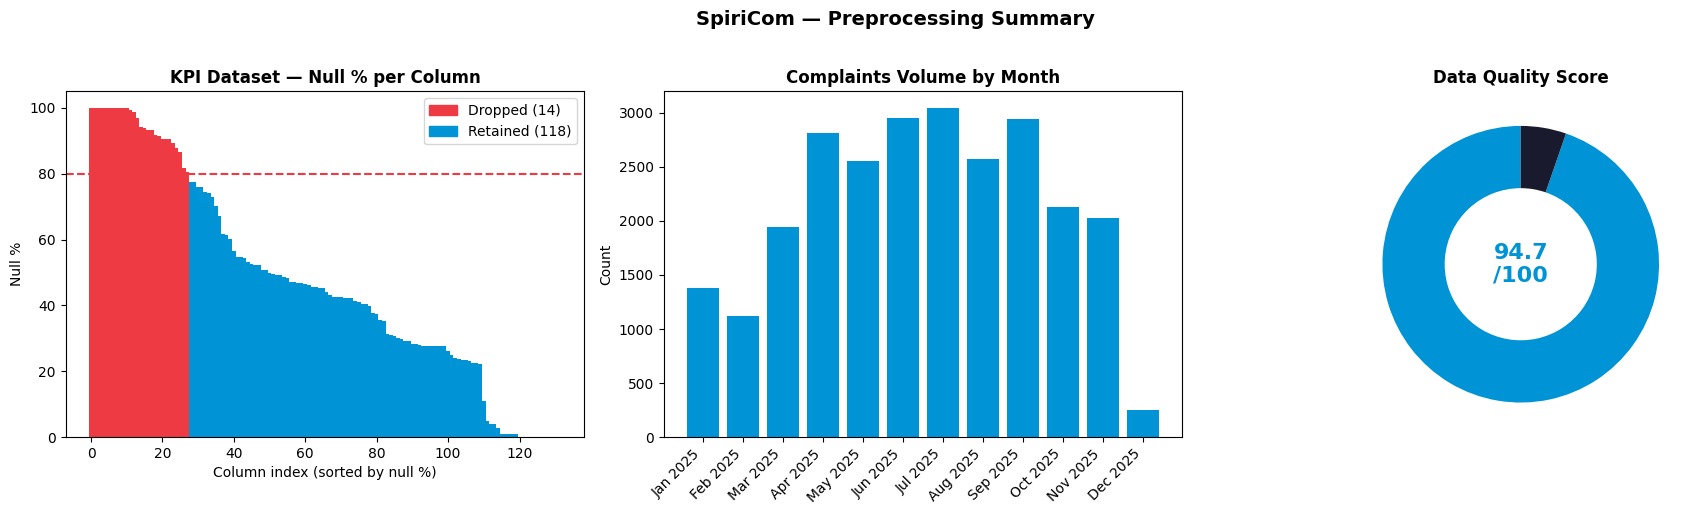

✅ Figure saved: data\processed\preprocessing_summary.png


In [24]:
# ── C.2  Visual summary ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SpiriCom — Preprocessing Summary', fontsize=14, fontweight='bold', y=1.02)

# 1 — Null % distribution for KPI dataset (before drop)
ax = axes[0]
null_vals = null_report.values
colors    = ['#EE3A43' if v >= 80 else '#0093D5' for v in null_vals]
ax.bar(range(len(null_vals)), sorted(null_vals, reverse=True), color=sorted(colors, reverse=True), width=1.0)
ax.axhline(80, color='#EE3A43', linestyle='--', linewidth=1.5, label='80% threshold')
ax.set_title('KPI Dataset — Null % per Column', fontweight='bold')
ax.set_xlabel('Column index (sorted by null %)')
ax.set_ylabel('Null %')
ax.legend()
dropped_patch   = mpatches.Patch(color='#EE3A43', label=f'Dropped ({len(cols_to_drop)})')
retained_patch  = mpatches.Patch(color='#0093D5', label=f'Retained ({len(cols_to_keep)})')
ax.legend(handles=[dropped_patch, retained_patch])

# 2 — Complaints by month
ax2 = axes[1]
if 'opened_at' in df_comp.columns:
    monthly = df_comp.set_index('opened_at').resample('M').size()
    ax2.bar(range(len(monthly)), monthly.values, color='#0093D5')
    ax2.set_xticks(range(len(monthly)))
    ax2.set_xticklabels([d.strftime('%b %Y') for d in monthly.index], rotation=45, ha='right')
    ax2.set_title('Complaints Volume by Month', fontweight='bold')
    ax2.set_ylabel('Count')

# 3 — Data quality donut
ax3 = axes[2]
sizes  = [quality_score, 100 - quality_score]
ccolors = ['#0093D5', '#1a1a2e']
ax3.pie(sizes, colors=ccolors, startangle=90,
        wedgeprops=dict(width=0.45))
ax3.text(0, 0, f'{quality_score}\n/100', ha='center', va='center',
         fontsize=16, fontweight='bold', color='#0093D5')
ax3.set_title('Data Quality Score', fontweight='bold')

plt.tight_layout()
fig_path = PROC_DIR / 'preprocessing_summary.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Figure saved: {fig_path}')

In [25]:
# ── C.3  Final summary table ─────────────────────────────────────────
summary = pd.DataFrame([
    ['real_complaints.xlsx',  df_comp.shape[0], 17, df_comp.shape[1],
     0, 'complaints_clean.parquet'],
    ['dataCollectionist.csv', 4899, len(cols_to_drop) + len(cols_to_keep),
     df_kpi.shape[1], len(cols_to_drop), 'kpi_clean.parquet'],
], columns=['File', 'Rows', 'Raw cols', 'Final cols', 'Dropped cols', 'Output'])

print('\n=== PREPROCESSING COMPLETE ===')
print(summary.to_string(index=False))
print(f'\nData quality score : {quality_score}/100')
print(f'Reports in         : {PROC_DIR.resolve()}')
print('\nNext → Run 01_Complaints_Analysis.ipynb')


=== PREPROCESSING COMPLETE ===
                 File  Rows  Raw cols  Final cols  Dropped cols                   Output
 real_complaints.xlsx 25727        17          23             0 complaints_clean.parquet
dataCollectionist.csv  4899       132         122            14        kpi_clean.parquet

Data quality score : 94.7/100
Reports in         : C:\Users\c50057188\Desktop\PFE_Ouerghi\data\processed

Next → Run 01_Complaints_Analysis.ipynb
